In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
df = pd.read_csv("cleaned_data.csv")

In [3]:
columns_to_drop = ['target', 'FT%', 'league_ft_pct', 'Player', 'Rk', 'Awards', 'Team', 'Pos', 'Season']
x = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

x = x.select_dtypes(include=[np.number])
y = df["target"]
print("Columns being used for training:", x.columns.tolist())

Columns being used for training: ['Age', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', 'FT', 'FTA', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# kernel='rbf' allows the model to draw curvy, complex boundaries instead of just straight lines
svc_model = SVC(kernel='rbf', random_state=42)

In [7]:
svc_model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [8]:
y_pred = svc_model.predict(X_test_scaled)

In [9]:
accuracy = accuracy_score(y_test, y_pred)
print(f"SVC Accuracy: {accuracy * 100:.2f}%\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

SVC Accuracy: 82.75%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84      2270
           1       0.85      0.77      0.81      1986

    accuracy                           0.83      4256
   macro avg       0.83      0.82      0.83      4256
weighted avg       0.83      0.83      0.83      4256



<Axes: >

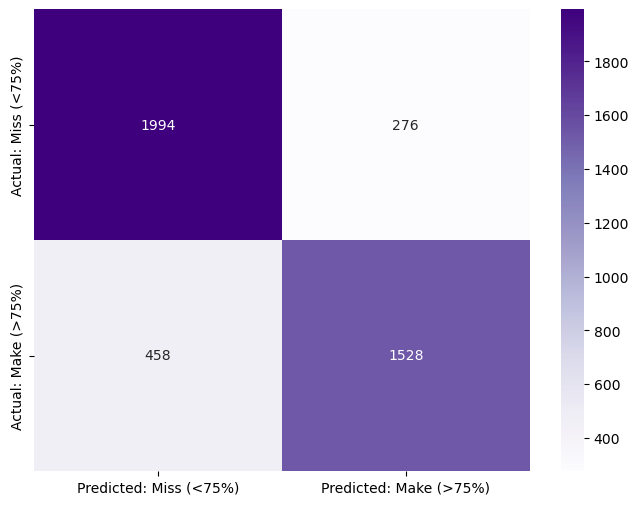

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Predicted: Miss (<75%)', 'Predicted: Make (>75%)'], 
            yticklabels=['Actual: Miss (<75%)', 'Actual: Make (>75%)'])

In [11]:
plt.savefig('svc_confusion_matrix.png', bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [12]:
joblib.dump(svc_model, "svc.pkl")
joblib.dump(scaler, "svc_scaler.pkl")

['svc_scaler.pkl']